# Supervised Learning – Baseline Model Comparison

This notebook establishes baseline supervised learning models
for diabetes risk prediction.

The objective of this stage is **model benchmarking**:
- compare multiple classification algorithms on the same dataset,
- evaluate their predictive performance,
- select a suitable model for subsequent feature engineering
  and resampling experiments.

At this stage:
- no resampling is applied,
- no feature merging is applied,
- interpretability and robustness are prioritised.


## 1. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

sns.set_style("whitegrid")


## 2. Load Dataset

In [12]:
df = pd.read_csv("../data/diabetes_processed.csv")

# Binary target:
# 0 = no diabetes
# 1 = prediabetes or diabetes
y = df["Diabetes_binary"]

## 3. Target Variable and Class Distribution

The binary target variable is defined as:
- 0: non-diabetic
- 1: diabetic (including prediabetes)

Class distribution is examined to assess imbalance.

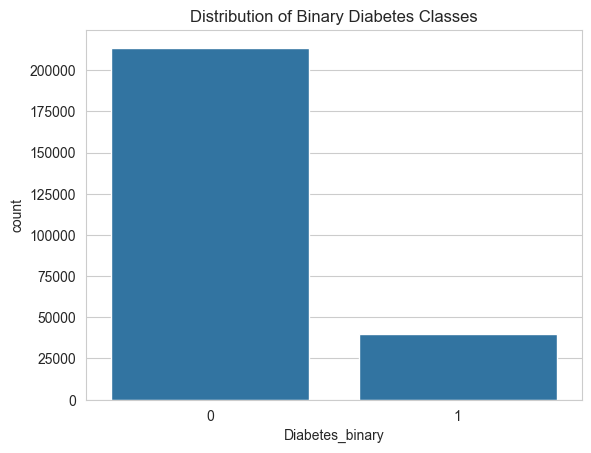

In [13]:
df['Diabetes_binary'].value_counts(normalize=True)
sns.countplot(x='Diabetes_binary', data=df)
plt.title("Distribution of Binary Diabetes Classes")
plt.show()

The dataset exhibits a clear class imbalance, with diabetic cases representing
a minority of the population. This has important implications for model
evaluation and metric selection.

## 4. Feature Selection

Feature selection was guided by:
- domain knowledge in public health and diabetes risk factors,
- exploratory data analysis (distributional differences),
- the need for interpretability in a baseline model.

Only a limited subset of clinically meaningful features was retained to
balance predictive performance and interpretability.


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

features_clf = df.columns.drop(['Diabetes_binary'])
target = "Diabetes_binary"

X = df[features_clf]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_scaled, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [15]:
coef_df = pd.DataFrame({
    'feature': features_clf,
    'coefficient': log_reg.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)

coef_df


,feature,coefficient
13,GenHlth,0.587020
3,BMI,0.484859
18,Age,0.457165
0,HighBP,0.340495
1,HighChol,0.294048
2,CholCheck,0.231553
10,HvyAlcoholConsump,-0.148657
20,Income,-0.129141
17,Sex,0.127098
6,HeartDiseaseorAttack,0.065079


C:\Users\18174\AppData\Local\Temp\ipykernel_28224\2751736788.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=coef_df, palette='coolwarm')


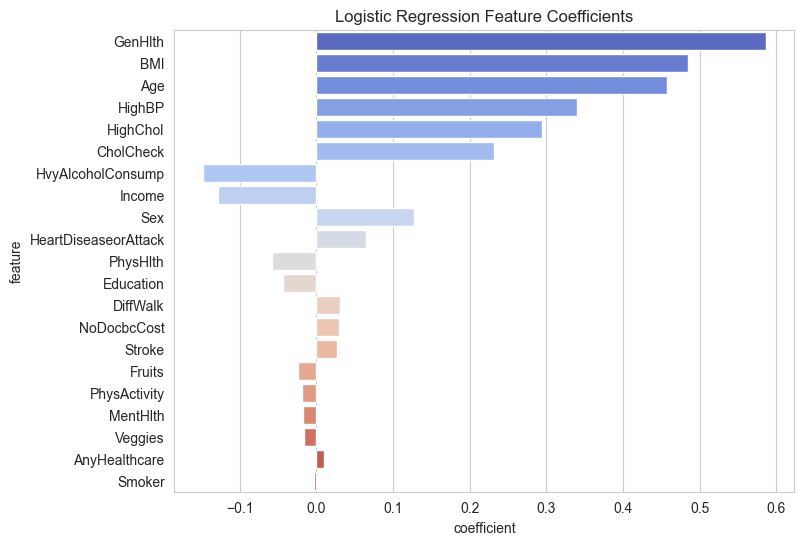

In [16]:
plt.figure(figsize=(8,6))
sns.barplot(x='coefficient', y='feature', data=coef_df, palette='coolwarm')
plt.title("Logistic Regression Feature Coefficients")
plt.show()


Logistic Regression coefficients indicate marginal linear effects.
Some variables showed small coefficients but remained clinically or socially meaningful.
Instead of removing them, domain-driven feature engineering was applied to aggregate related variables into higher-level constructs.

For the baseline supervised model, feature selection prioritised interpretability and clinical relevance.
Rather than using all available variables, a subset of well-established diabetes risk factors was retained,
including BMI, age, hypertension, cholesterol status, and general health.
Behavioural and socioeconomic factors were minimally represented to preserve model simplicity.
This baseline serves as a transparent reference point for subsequent feature engineering and resampling experiments.

In [18]:
baseline_features = [ "BMI", "Age", "HighBP", "HighChol", "GenHlth", "HvyAlcoholConsump", "Income", "Sex" ]

## 5. Train–Test Split

The dataset was split into training and testing sets to evaluate the generalisation
performance of the baseline model. Stratified sampling was applied to preserve the
class distribution due to class imbalance.

In [19]:
from sklearn.model_selection import train_test_split

X = df[baseline_features]
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True))


Training set class distribution:
Diabetes_binary
0    0.84241
1    0.15759
Name: proportion, dtype: float64

Test set class distribution:
Diabetes_binary
0    0.84242
1    0.15758
Name: proportion, dtype: float64


## 6. Define Baseline Models

Models were selected to represent different learning paradigms:
- linear probabilistic model (Logistic Regression),
- margin-based classifier (SVM),
- instance-based learning (KNN),

In [48]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(solver="liblinear", max_iter=500))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])
}

In [58]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100], 
        "model__penalty": ['l2']
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7],  # 3 个值
        "model__weights": ['uniform', 'distance'],    
        "model__metric": ['euclidean', 'manhattan']    
    }
}


In [61]:
import time
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score
from sklearn.model_selection import ParameterGrid, cross_val_score
from tqdm import tqdm


results = []
best_models = {}

total_models = len(models)
for idx, (name, model) in enumerate(models.items(), 1):
    print(f"[{idx}/{total_models}] Starting tuning: {name}...")

    param_grid = list(ParameterGrid(param_grids[name]))
    best_score = -1
    best_params = None
    best_estimator = None

    start_time_model = time.time()

    # tqdm 进度条
    for params in tqdm(param_grid, desc=f"Tuning {name}", unit="param"):
        model.set_params(**params)
        # 用交叉验证计算评分
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
        mean_score = scores.mean()

        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            best_estimator = model

    # 保存最优模型
    best_estimator.set_params(**best_params)
    best_models[name] = best_estimator
    best_estimator.fit(X_train, y_train) 
    acc = accuracy_score(y_test, best_estimator.predict(X_test))

    results.append({
        "Model": name,
        "Best Params": best_params,
        "CV Accuracy": best_score,
        "Test Accuracy": acc
    })

    elapsed = time.time() - start_time_model
    print(f"[{idx}/{total_models}] Finished {name} in {elapsed:.1f} sec | Test Accuracy: {acc:.4f}\n")

# 汇总结果
results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)
print("All models finished. Summary:")
print(results_df)

[1/2] Starting tuning: Logistic Regression...


Tuning Logistic Regression: 100%|██████████| 5/5 [00:02<00:00,  2.13param/s]
d:\anaconda3\envs\dm_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[1/2] Finished Logistic Regression in 2.5 sec | Test Accuracy: 0.8481

[2/2] Starting tuning: KNN...


Tuning KNN: 100%|██████████| 12/12 [00:52<00:00,  4.40s/param]


[2/2] Finished KNN in 56.5 sec | Test Accuracy: 0.8361

All models finished. Summary:
                 Model                                        Best Params  \
0  Logistic Regression         {'model__C': 0.01, 'model__penalty': 'l2'}   
1                  KNN  {'model__metric': 'euclidean', 'model__n_neigh...   

   CV Accuracy  Test Accuracy  
0     0.847426       0.848057  
1     0.836807       0.836112  


The time complexity of SVM with nonlinear kernels is too high on large-scale training datasets, and the training efficiency is too low. Therefore, it is not considered for the time being.

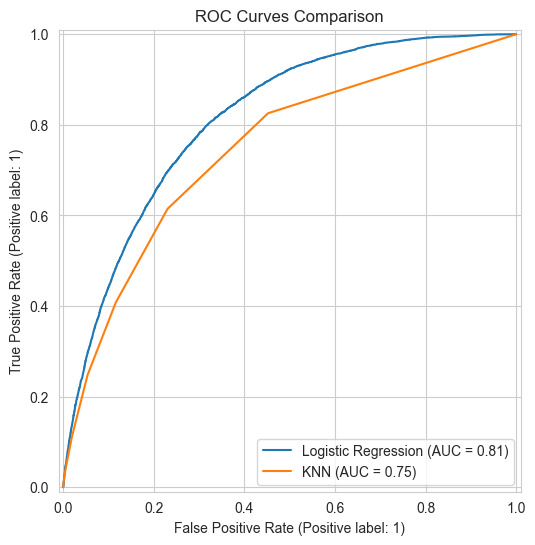

In [62]:
from sklearn.metrics import RocCurveDisplay
# ===== 可视化 ROC 曲线 =====
plt.figure(figsize=(8,6))
for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=plt.gca())
plt.title("ROC Curves Comparison")
plt.show()

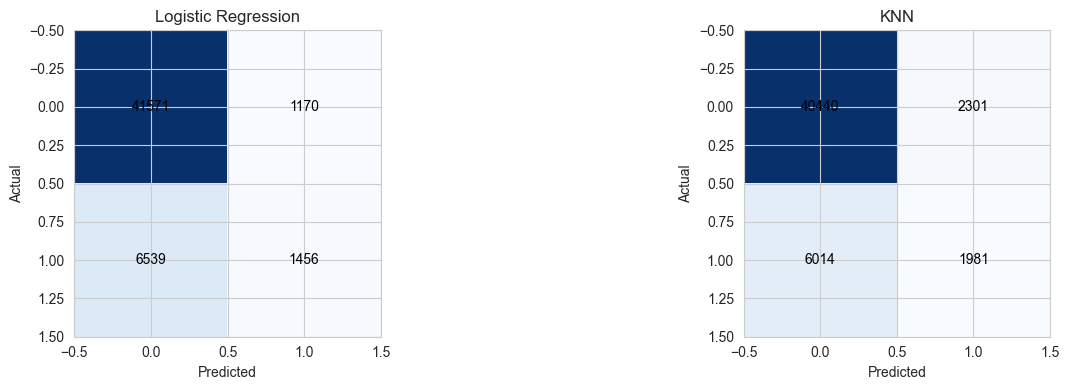

In [63]:
# ===== 混淆矩阵对比 =====
fig, axes = plt.subplots(1, 2, figsize=(15,4))
for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i,j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

In [64]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# 初始化列表存储结果
metrics_list = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    
    # 对于 ROC AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        y_score = model.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_score)
    
    metrics_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC AUC": roc_auc
    })

# 转成 DataFrame，方便展示
import pandas as pd
metrics_df = pd.DataFrame(metrics_list).sort_values("ROC AUC", ascending=False)
metrics_df


,Model,Accuracy,F1 Score,Precision,Recall,ROC AUC
0,Logistic Regression,0.848057,0.274174,0.554455,0.182114,0.814229
1,KNN,0.836112,0.322717,0.462634,0.247780,0.745923


It can be seen that the accuracy, precision and ROC AUC of KNN are all lower than those of logistic regression, but the F1 score and recall of KNN are higher than those of logistic regression. Our goal is to identify as many diabetic patients as possible. Therefore, we tend to choose KNN with a higher recall, even if it means sacrificing a small portion of accuracy.